# Activity Distance: Bootstrap-Corrected Synchrony

This notebook estimates distance-dependent spike synchrony during high-activity periods without using `FiringDistanceAnalyzer`.

The central measurement is conditional firing probability:

```text
P(target electrode fires near reference electrode spike | reference electrode spike, high-activity period)
```

It then subtracts a within-interval jitter null so high baseline firing during active states is not mistaken for fine-timescale synchrony. The output is progression-ready: the same code can run one well, all wells for one DIV, or all configured wells over multiple DIVs.

In [ ]:
%matplotlib inline

import os
import sys
import pickle
import warnings
import hashlib
import json
from pathlib import Path

import numpy as np
warnings.filterwarnings("ignore", message="Pandas requires version .* of 'numexpr'.*")
warnings.filterwarnings("ignore", message="Pandas requires version .* of 'bottleneck'.*")
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import f as f_distribution

repo_root = Path.cwd()
if not (repo_root / "ephax").exists() and (repo_root.parent / "ephax").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

os.environ.setdefault("MPLCONFIGDIR", str((repo_root / ".mpl-cache").resolve()))

import matplotlib.pyplot as plt

from ephax import PrepConfig, RestingActivityDataset
from ephax.metrics import (
    build_highres_traces,
    build_participation_activity_state,
    build_population_ifr,
    detect_high_activity_epochs,
    detect_participation_burst_epochs,
)
from ephax.modeling import HDMEADifferentiationConfig, correlation_function

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 120)
np.random.seed(0)

## Configuration

`SMOKE_MODE=True` keeps the first run small. Set it to `False` for the production settings immediately below it. The effective settings are included in the cache key, so smoke and production outputs are stored separately.

In [ ]:
# Dataset switch: "stim_removal_null" or "raw_h5".
DATASET = "stim_removal_null"

# Scope switch: "single_recording", "single_div_all_wells", or "div_progression".
RUN_MODE = "single_div_all_wells"

# Single-recording selection. DIV is used by stimRemovalNull and ignored for raw H5.
WELL = 0
DIV = 12
DIVS = [DIV]
RAW_H5_DIV = 40

STIM_DATA_ROOT = repo_root / "ephax/data/stimRemovalNull"
STIM_DATA_FILENAME_TEMPLATE = "DIV{div}_240703_data_well{well}_exp_data.npz"

H5_FILE_INFO = {
    0: ("ephax/data", "well_0.raw.h5", 0),
    1: ("ephax/data", "well_1.raw.h5", 1),
    2: ("ephax/data", "well_2_3.raw.h5", 2),
    3: ("ephax/data", "well_2_3.raw.h5", 3),
    4: ("ephax/data", "well_4.raw.h5", 4),
    5: ("ephax/data", "well_5.raw.h5", 5),
}

AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
AGGREGATE_DIVS = [DIV]

START_SEC = 0.0
END_SEC = 300.0 if DATASET == "stim_removal_null" else 600.0
MIN_AMP = 0.0

# Some stimRemovalNull NPZ files store absolute experiment times rather than times starting near 0.
# If the requested absolute window contains no spikes, shift [START_SEC, END_SEC] to the file spike onset.
AUTO_ALIGN_EMPTY_WINDOW_TO_SPIKE_ONSET = True

TOP_START = 0
TOP_STOP = 1000 if DATASET == "stim_removal_null" else 300

# High-activity settings aligned with burst_analysis.ipynb.
IFR_GRID_HZ = 50.0
SMOOTH_SIGMA_SEC = 0.15
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0

# Burst exclusion/isolation uses participation bursts inside high-activity periods.
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
NETWORK_BIN_MS = 10.0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_DURATION_MS = 20.0

# Temporal subsetting for synchrony.
# Use "high_activity" to analyze all high-activity periods, "burst" to analyze burst periods only,
# or "high_activity_non_burst" to remove burst periods from high-activity periods.
TEMPORAL_SUBSET = "burst"
TEMPORAL_SUBSET_ALIASES = {
    "high_activity": "high_activity_all",
    "high_activity_all": "high_activity_all",
    "high_activity_non_burst": "high_activity_non_burst",
    "burst": "burst",
}
if TEMPORAL_SUBSET not in TEMPORAL_SUBSET_ALIASES:
    raise ValueError(f"TEMPORAL_SUBSET must be one of {sorted(TEMPORAL_SUBSET_ALIASES)}")
SYNC_ACTIVITY_SCOPE = TEMPORAL_SUBSET_ALIASES[TEMPORAL_SUBSET]

PRIMARY_LAG_WINDOW_MS = (-2.0, 2.0)
DIRECTED_LAG_WINDOWS_MS = [(0.0, 5.0), (0.0, 10.0), (0.0, 20.0)]
# Computing all directed windows multiplies runtime; keep False until the primary synchrony curve looks sane.
SYNC_EVALUATE_DIRECTED_LAG_WINDOWS = False
SYNC_LAG_WINDOWS_MS = [PRIMARY_LAG_WINDOW_MS] + (DIRECTED_LAG_WINDOWS_MS if SYNC_EVALUATE_DIRECTED_LAG_WINDOWS else [])
# Fast default: interval-rate expectation preserves each interval's target event probability.
# Slower confirmatory option: "interval_jitter".
SYNC_NULL_METHOD = "interval_jitter"  # "rate_expectation" or "interval_jitter"
SYNC_JITTER_MS = 25.0
SYNC_BOOTSTRAP_REPS = 200
SYNC_N_SURROGATES = 100
SYNC_N_REF_ELECTRODES = 150
SYNC_N_TARGET_ELECTRODES = 300
# Matrix mode is much faster than pair-loop mode: it builds binary spike matrices
# per interval and computes all pair coincidences with matrix multiplication.
SYNC_COMPUTE_METHOD = "matrix"  # "matrix" or "pair_loop"
SYNC_MATRIX_BIN_MS = 1.0

# Pair-loop fallback settings. Matrix mode ignores pair sampling and uses all pairs.
SYNC_PAIR_SAMPLING = "distance_stratified"  # "distance_stratified" or "random_ref_target"
SYNC_PAIRS_PER_DISTANCE_BIN = 250
SYNC_MIN_TRIGGER_SPIKES = 5
SYNC_NULL_STD_FLOOR = 1e-4
SYNC_RANDOM_SEED = 0

# Distance binning.
MIN_DISTANCE_UM = 50.0
MAX_DISTANCE_UM = 3500.0
DISTANCE_BIN_UM = 100.0
MIN_PAIRS_PER_DISTANCE_BIN = 20

# Use the exact Figure 1 correlation-wave definition. Frequency and velocities fix
# its 2539.68 um spatial wavelength. The attenuation lengths below are optimizer
# starting points only: both are fitted from the synchrony data.
MODEL_INITIAL_LAMBDA_EPH_UM = 3000.0
MODEL_INITIAL_AXONAL_DECAY_UM = 200.0
FIGURE1_WAVE_CONFIG = HDMEADifferentiationConfig(
    hz=45.0,
    v_eph_m_s=0.1,
    v_ax_m_s=0.8,
    lambda_eph_um=MODEL_INITIAL_LAMBDA_EPH_UM,
    axonal_decay_um=MODEL_INITIAL_AXONAL_DECAY_UM,
)
MODEL_FIT_BOOTSTRAP_REPS = 1000
MODEL_FIT_RANDOM_SEED = 0

OUTPUT_ROOT = repo_root / "outputs" / "activity_distance"
FORCE_RECOMPUTE = False

# First-run settings. Disable for production.
SMOKE_MODE = True
if SMOKE_MODE:
    SYNC_BOOTSTRAP_REPS = 5
    SYNC_N_SURROGATES = 5 if SYNC_NULL_METHOD == "rate_expectation" else 5
    SYNC_N_REF_ELECTRODES = 30
    SYNC_N_TARGET_ELECTRODES = 60

## Recording Specs and Loaders

In [216]:
def stim_recording_path(well, div):
    return STIM_DATA_ROOT / f"well{int(well)}" / STIM_DATA_FILENAME_TEMPLATE.format(div=int(div), well=int(well))


def build_recording_spec(well, div=None):
    if DATASET == "stim_removal_null":
        div = DIV if div is None else int(div)
        path = stim_recording_path(well, div)
        if not path.exists():
            raise FileNotFoundError(f"Could not find stimRemovalNull recording file: {path}")
        return {
            "dataset": DATASET,
            "source": "npz",
            "path": path,
            "well": int(well),
            "div": int(div),
            "recording_id": f"stimRemovalNull_well{int(well)}_DIV{int(div)}",
            "label": f"stimRemovalNull well{int(well)} DIV{int(div)}",
            "source_file": path.name,
        }

    if DATASET == "raw_h5":
        if int(well) not in H5_FILE_INFO:
            raise ValueError(f"Unsupported raw H5 WELL={well}; available wells: {sorted(H5_FILE_INFO)}")
        h5_folder, h5_filename, h5_well_index = H5_FILE_INFO[int(well)]
        folder_path = repo_root / h5_folder
        file_path = folder_path / h5_filename
        if not file_path.exists():
            raise FileNotFoundError(f"Could not find raw H5 recording file: {file_path}")
        return {
            "dataset": DATASET,
            "source": "h5",
            "folder": folder_path,
            "filename": h5_filename,
            "path": file_path,
            "well": int(well),
            "h5_well_index": int(h5_well_index),
            "div": int(RAW_H5_DIV),
            "recording_id": f"raw_h5_well{int(well)}_DIV{int(RAW_H5_DIV)}",
            "label": f"raw H5 well{int(well)} DIV{int(RAW_H5_DIV)}",
            "source_file": h5_filename,
        }

    raise ValueError("DATASET must be 'stim_removal_null' or 'raw_h5'.")


def iter_recording_specs():
    if RUN_MODE == "single_recording":
        yield build_recording_spec(WELL, DIV)
        return

    if RUN_MODE == "single_div_all_wells":
        divs = [DIV]
        wells = AGGREGATE_WELLS
    elif RUN_MODE == "div_progression":
        divs = list(DIVS)
        wells = AGGREGATE_WELLS
    else:
        raise ValueError("RUN_MODE must be 'single_recording', 'single_div_all_wells', or 'div_progression'.")

    for div in divs:
        for well in wells:
            try:
                yield build_recording_spec(well, div)
            except FileNotFoundError as exc:
                print(f"Skipping missing recording: {exc}")


def npz_spike_time_range(path, min_amp=MIN_AMP):
    data = np.load(path, allow_pickle=True)
    sf = float(data["samp_rate"])
    spikes = data["spike_data"]
    times = np.asarray(spikes["frameno"], dtype=float) / sf
    amplitudes = np.abs(np.asarray(spikes["amplitude"], dtype=float))
    valid = np.isfinite(times) & (amplitudes >= float(min_amp))
    if not np.any(valid):
        return np.nan, np.nan, 0
    return float(np.nanmin(times[valid])), float(np.nanmax(times[valid])), int(np.count_nonzero(valid))


def resolve_recording_window_for_spec(spec, start_sec=START_SEC, end_sec=END_SEC, min_amp=MIN_AMP):
    start = float(start_sec)
    end = float(end_sec)
    if spec["source"] != "npz" or not AUTO_ALIGN_EMPTY_WINDOW_TO_SPIKE_ONSET:
        return start, end, "configured"

    t_min, t_max, n_spikes = npz_spike_time_range(spec["path"], min_amp=min_amp)
    if n_spikes == 0 or not np.isfinite(t_min) or not np.isfinite(t_max):
        return start, end, "configured_empty_file"

    has_spikes_in_configured_window = (t_max >= start) and (t_min <= end)
    if has_spikes_in_configured_window:
        return start, end, "configured"

    duration = max(0.0, end - start)
    shifted_start = t_min + start
    shifted_end = min(t_max, shifted_start + duration) if duration > 0 else t_max
    if shifted_end <= shifted_start:
        shifted_end = t_max
    return float(shifted_start), float(shifted_end), "shifted_to_spike_onset"


def load_recording_from_spec(spec, start_sec=START_SEC, end_sec=END_SEC, min_amp=MIN_AMP):
    if spec["source"] == "npz":
        resolved_start, resolved_end, window_mode = resolve_recording_window_for_spec(spec, start_sec, end_sec, min_amp)
        spec["resolved_start_sec"] = resolved_start
        spec["resolved_end_sec"] = resolved_end
        spec["window_mode"] = window_mode
        file_info = [(str(spec["path"]), resolved_start, resolved_end, int(spec["well"]))]
        return RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=float(min_amp))

    if spec["source"] == "h5":
        spec["resolved_start_sec"] = float(start_sec)
        spec["resolved_end_sec"] = float(end_sec)
        spec["window_mode"] = "configured"
        file_info = [(str(spec["folder"]), str(spec["filename"]), float(start_sec), float(end_sec), int(spec["h5_well_index"]))]
        return RestingActivityDataset.from_file_info(file_info, source="h5", min_amp=float(min_amp))

    raise ValueError(f"Unsupported source: {spec['source']}")


recording_specs = list(iter_recording_specs())
recording_spec_table = pd.DataFrame(recording_specs)
if recording_spec_table.empty:
    raise ValueError("No recordings were found for the configured scope.")
recording_spec_table[["dataset", "well", "div", "recording_id", "source_file"]]

,dataset,well,div,recording_id,source_file
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,DIV12_240703_data_well0_exp_data.npz
1,stim_removal_null,1,12,stimRemovalNull_well1_DIV12,DIV12_240703_data_well1_exp_data.npz
2,stim_removal_null,2,12,stimRemovalNull_well2_DIV12,DIV12_240703_data_well2_exp_data.npz
3,stim_removal_null,3,12,stimRemovalNull_well3_DIV12,DIV12_240703_data_well3_exp_data.npz
4,stim_removal_null,4,12,stimRemovalNull_well4_DIV12,DIV12_240703_data_well4_exp_data.npz
5,stim_removal_null,5,12,stimRemovalNull_well5_DIV12,DIV12_240703_data_well5_exp_data.npz


## Interval Detection

In [217]:
def _empty_intervals():
    return pd.DataFrame(columns=["event_idx", "start_time_s", "end_time_s", "duration_s"])


def normalize_intervals(df):
    if df is None or len(df) == 0:
        return _empty_intervals()
    out = df.copy()
    if not {"start_time_s", "end_time_s"}.issubset(out.columns):
        raise ValueError("interval table must contain start_time_s and end_time_s")
    out["start_time_s"] = out["start_time_s"].astype(float)
    out["end_time_s"] = out["end_time_s"].astype(float)
    out = out[np.isfinite(out["start_time_s"]) & np.isfinite(out["end_time_s"])]
    out = out[out["end_time_s"] > out["start_time_s"]]
    out = out.sort_values("start_time_s", ignore_index=True)
    out["duration_s"] = out["end_time_s"] - out["start_time_s"]
    if "event_idx" not in out:
        out["event_idx"] = np.arange(len(out), dtype=int)
    return out


def subtract_intervals(base_df, remove_df):
    base = normalize_intervals(base_df)
    remove = normalize_intervals(remove_df)
    if base.empty or remove.empty:
        return base.copy()

    rows = []
    for _, b in base.iterrows():
        pieces = [(float(b.start_time_s), float(b.end_time_s))]
        overlaps = remove[(remove["end_time_s"] > b.start_time_s) & (remove["start_time_s"] < b.end_time_s)]
        for _, r in overlaps.iterrows():
            new_pieces = []
            rs, re = float(r.start_time_s), float(r.end_time_s)
            for ps, pe in pieces:
                if re <= ps or rs >= pe:
                    new_pieces.append((ps, pe))
                    continue
                if rs > ps:
                    new_pieces.append((ps, min(rs, pe)))
                if re < pe:
                    new_pieces.append((max(re, ps), pe))
            pieces = [(ps, pe) for ps, pe in new_pieces if pe > ps]
        for ps, pe in pieces:
            rows.append({"start_time_s": ps, "end_time_s": pe})
    out = pd.DataFrame(rows)
    if out.empty:
        return _empty_intervals()
    out["event_idx"] = np.arange(len(out), dtype=int)
    out["duration_s"] = out["end_time_s"] - out["start_time_s"]
    return out


def choose_activity_intervals(high_epochs, burst_epochs, scope):
    high_epochs = normalize_intervals(high_epochs)
    burst_epochs = normalize_intervals(burst_epochs)
    if scope == "high_activity_all":
        return high_epochs
    if scope == "burst":
        return burst_epochs
    if scope == "high_activity_non_burst":
        return subtract_intervals(high_epochs, burst_epochs)
    raise ValueError("SYNC_ACTIVITY_SCOPE must be 'high_activity_non_burst', 'high_activity_all', or 'burst'.")


def skipped_recording_result(spec, reason, rec=None, refs=None):
    if rec is not None:
        in_window = (rec.spikes["time"] >= rec.start_time) & (rec.spikes["time"] <= rec.end_time)
        n_spikes = int(np.sum(in_window))
        n_active = int(np.unique(rec.spikes["electrode"][in_window]).size) if n_spikes else 0
    else:
        n_spikes = 0
        n_active = 0
    summary = {
        "dataset": spec["dataset"],
        "well": int(spec["well"]),
        "div": spec.get("div", np.nan),
        "recording_id": spec["recording_id"],
        "source_file": spec["source_file"],
        "window_mode": spec.get("window_mode", "unknown"),
        "resolved_start_sec": spec.get("resolved_start_sec", np.nan),
        "resolved_end_sec": spec.get("resolved_end_sec", np.nan),
        "valid_for_sync": False,
        "skip_reason": str(reason),
        "n_spikes": n_spikes,
        "n_active_electrodes": n_active,
        "n_refs": int(len(refs)) if refs is not None else 0,
        "n_high_activity_periods": 0,
        "n_burst_periods": 0,
        "n_selected_periods": 0,
        "selected_duration_s": 0.0,
        "high_activity_threshold_hz": np.nan,
    }
    return {
        "spec": spec,
        "dataset": None,
        "recording": rec,
        "refs": np.asarray([] if refs is None else refs, dtype=int),
        "population": None,
        "high_epochs": _empty_intervals(),
        "burst_epochs": _empty_intervals(),
        "selected_intervals": _empty_intervals(),
        "summary": summary,
    }


def detect_recording_activity(spec):
    try:
        ds = load_recording_from_spec(spec)
    except Exception as exc:
        return skipped_recording_result(spec, f"load failed: {exc}")

    rec = ds.recordings[0]
    prep_cfg = PrepConfig(mode="top", top_start=TOP_START, top_stop=TOP_STOP, verbose=False)
    refs = ds.select_ref_electrodes(prep_cfg)[0]
    if len(refs) == 0:
        return skipped_recording_result(spec, "no selected reference electrodes", rec=rec, refs=refs)

    try:
        population = build_population_ifr(rec, refs, grid_hz=IFR_GRID_HZ, smooth_sigma_sec=SMOOTH_SIGMA_SEC)
    except ValueError as exc:
        return skipped_recording_result(spec, f"population IFR unavailable: {exc}", rec=rec, refs=refs)

    high_epochs, high_info = detect_high_activity_epochs(
        population.time_grid,
        population.mean_ifr_smooth,
        mad_scale=HIGH_ACTIVITY_MAD_SCALE,
        min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
        max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    )

    try:
        highres = build_highres_traces(rec, refs, bin_ms=HIGHRES_BIN_MS, smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS)
        participation = build_participation_activity_state(highres, aggregation_ms=NETWORK_BIN_MS)
        burst_epochs = detect_participation_burst_epochs(
            participation,
            high_epochs,
            min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
            min_duration_ms=NETWORK_MIN_DURATION_MS,
        )
    except ValueError:
        burst_epochs = _empty_intervals()

    selected_intervals = choose_activity_intervals(high_epochs, burst_epochs, SYNC_ACTIVITY_SCOPE)
    selected_intervals = normalize_intervals(selected_intervals)

    in_window = (rec.spikes["time"] >= rec.start_time) & (rec.spikes["time"] <= rec.end_time)
    valid_for_sync = bool(len(selected_intervals) > 0)
    summary = {
        "dataset": spec["dataset"],
        "well": int(spec["well"]),
        "div": spec.get("div", np.nan),
        "recording_id": spec["recording_id"],
        "source_file": spec["source_file"],
        "window_mode": spec.get("window_mode", "unknown"),
        "resolved_start_sec": spec.get("resolved_start_sec", np.nan),
        "resolved_end_sec": spec.get("resolved_end_sec", np.nan),
        "valid_for_sync": valid_for_sync,
        "skip_reason": "" if valid_for_sync else f"no intervals for scope {SYNC_ACTIVITY_SCOPE}",
        "n_spikes": int(np.sum(in_window)),
        "n_active_electrodes": int(np.unique(rec.spikes["electrode"][in_window]).size),
        "n_refs": int(len(refs)),
        "n_high_activity_periods": int(len(high_epochs)),
        "n_burst_periods": int(len(burst_epochs)),
        "n_selected_periods": int(len(selected_intervals)),
        "selected_duration_s": float(selected_intervals["duration_s"].sum()) if not selected_intervals.empty else 0.0,
        "high_activity_threshold_hz": float(high_info.get("threshold_hz", np.nan)),
    }
    return {
        "spec": spec,
        "dataset": ds,
        "recording": rec,
        "refs": np.asarray(refs, dtype=int),
        "population": population,
        "high_epochs": normalize_intervals(high_epochs),
        "burst_epochs": normalize_intervals(burst_epochs),
        "selected_intervals": selected_intervals,
        "summary": summary,
    }


all_activity_results = [detect_recording_activity(spec) for spec in recording_specs]
recording_summary = pd.DataFrame([item["summary"] for item in all_activity_results])
activity_results = [item for item in all_activity_results if item["summary"].get("valid_for_sync", False)]
if not activity_results:
    display(recording_summary)
    raise ValueError("No recordings are valid for synchrony analysis. Inspect recording_summary['skip_reason'].")
recording_summary

,dataset,well,div,recording_id,source_file,window_mode,resolved_start_sec,resolved_end_sec,valid_for_sync,skip_reason,n_spikes,n_active_electrodes,n_refs,n_high_activity_periods,n_burst_periods,n_selected_periods,selected_duration_s,high_activity_threshold_hz
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,DIV12_240703_data_well0_exp_data.npz,configured,0.0,300.0,True,,129192,998,998,14,66,66,4.81,0.193353
1,stim_removal_null,1,12,stimRemovalNull_well1_DIV12,DIV12_240703_data_well1_exp_data.npz,configured,0.0,300.0,True,,108847,1002,1000,11,68,68,4.62,0.125421
2,stim_removal_null,2,12,stimRemovalNull_well2_DIV12,DIV12_240703_data_well2_exp_data.npz,configured,0.0,300.0,True,,114568,987,987,15,44,44,2.56,0.200622
3,stim_removal_null,3,12,stimRemovalNull_well3_DIV12,DIV12_240703_data_well3_exp_data.npz,configured,0.0,300.0,True,,112949,1001,1000,11,63,63,3.71,0.203911
4,stim_removal_null,4,12,stimRemovalNull_well4_DIV12,DIV12_240703_data_well4_exp_data.npz,configured,0.0,300.0,True,,97508,980,980,16,52,52,3.58,0.152112
5,stim_removal_null,5,12,stimRemovalNull_well5_DIV12,DIV12_240703_data_well5_exp_data.npz,configured,0.0,300.0,True,,112212,994,994,14,69,69,5.84,0.153437


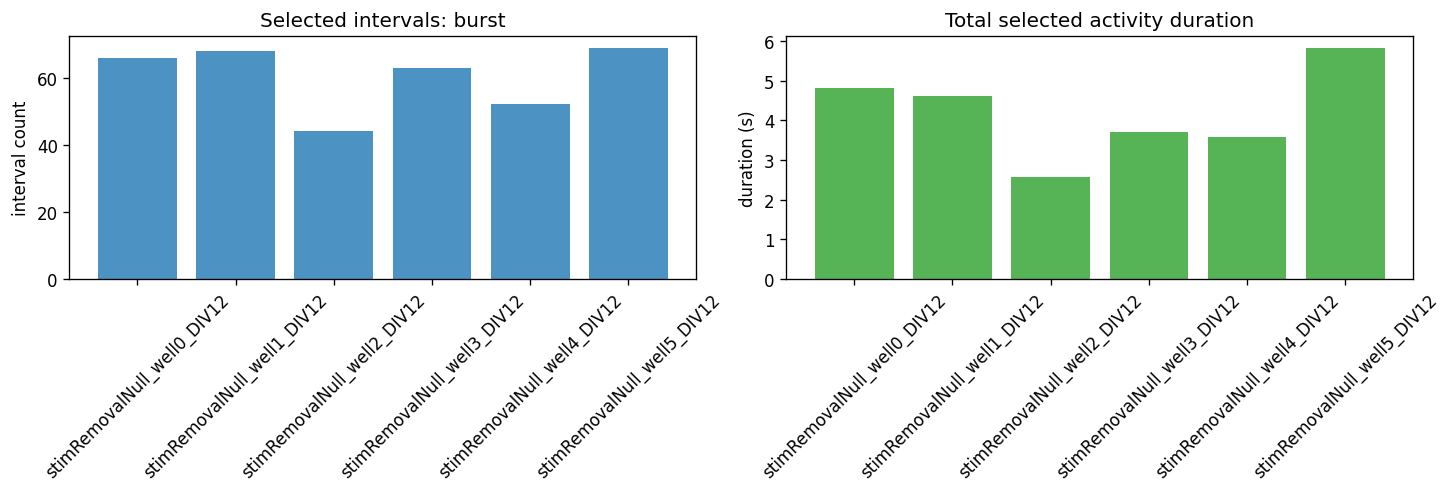

,dataset,well,div,recording_id,interval_kind,event_idx,start_time_s,end_time_s,duration_s
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,0,15.66,21.52,5.86
1,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,1,39.82,44.84,5.02
2,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,2,61.34,66.32,4.98
3,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,3,81.18,87.06,5.88
4,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,4,104.04,109.10,5.06


In [218]:
interval_rows = []
for item in activity_results:
    spec = item["spec"]
    for interval_kind, intervals in [
        ("high_activity", item["high_epochs"]),
        ("burst", item["burst_epochs"]),
        (SYNC_ACTIVITY_SCOPE, item["selected_intervals"]),
    ]:
        for _, row in intervals.iterrows():
            interval_rows.append(
                {
                    "dataset": spec["dataset"],
                    "well": int(spec["well"]),
                    "div": spec.get("div", np.nan),
                    "recording_id": spec["recording_id"],
                    "interval_kind": interval_kind,
                    "event_idx": int(row.get("event_idx", len(interval_rows))),
                    "start_time_s": float(row["start_time_s"]),
                    "end_time_s": float(row["end_time_s"]),
                    "duration_s": float(row["duration_s"]),
                }
            )
interval_summary = pd.DataFrame(interval_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
plot_df = recording_summary.copy()
plot_df["label"] = plot_df["recording_id"].astype(str)
axes[0].bar(plot_df["label"], plot_df["n_selected_periods"], color="tab:blue", alpha=0.8)
axes[0].set_ylabel("interval count")
axes[0].set_title(f"Selected intervals: {SYNC_ACTIVITY_SCOPE}")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(plot_df["label"], plot_df["selected_duration_s"], color="tab:green", alpha=0.8)
axes[1].set_ylabel("duration (s)")
axes[1].set_title("Total selected activity duration")
axes[1].tick_params(axis="x", rotation=45)
plt.show()

interval_summary.head()

## Bootstrap-Corrected Conditional Synchrony

In [219]:
def electrode_coords_um(layout):
    df = pd.DataFrame(layout)
    df = df.dropna(subset=["electrode", "x", "y"])
    return df.drop_duplicates("electrode").set_index("electrode")[["x", "y"]].astype(float)


def distance_edges_and_centers():
    edges = np.arange(MIN_DISTANCE_UM, MAX_DISTANCE_UM + DISTANCE_BIN_UM, DISTANCE_BIN_UM, dtype=float)
    if edges[-1] < MAX_DISTANCE_UM:
        edges = np.append(edges, MAX_DISTANCE_UM)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return edges, centers


def build_pair_arrays(electrodes, coords_df):
    electrodes = np.asarray([int(e) for e in electrodes if int(e) in coords_df.index], dtype=int)
    if electrodes.size < 2:
        return electrodes, np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=float), np.array([], dtype=int), np.array([], dtype=float)
    xy = coords_df.loc[electrodes, ["x", "y"]].to_numpy(dtype=float)
    diff = xy[:, None, :] - xy[None, :, :]
    dist = np.sqrt(np.sum(diff * diff, axis=2))
    ref_idx, target_idx = np.where(~np.eye(electrodes.size, dtype=bool))
    distance_um = dist[ref_idx, target_idx]
    edges, centers = distance_edges_and_centers()
    bin_idx = np.searchsorted(edges, distance_um, side="right") - 1
    keep = (bin_idx >= 0) & (bin_idx < centers.size)
    return electrodes, ref_idx[keep], target_idx[keep], distance_um[keep], bin_idx[keep], centers


def build_pair_catalog(electrodes, coords_df):
    electrodes, ref_idx, target_idx, distance_um, bin_idx, centers = build_pair_arrays(electrodes, coords_df)
    if ref_idx.size == 0:
        return pd.DataFrame(columns=["ref_electrode", "target_electrode", "distance_um", "distance_bin_idx", "distance_bin_center_um"])
    return pd.DataFrame(
        {
            "ref_electrode": electrodes[ref_idx].astype(int),
            "target_electrode": electrodes[target_idx].astype(int),
            "distance_um": distance_um.astype(float),
            "distance_bin_idx": bin_idx.astype(int),
            "distance_bin_center_um": centers[bin_idx].astype(float),
        }
    )


def interval_spike_matrix(recording, electrodes, start_s, end_s, bin_ms):
    bin_s = float(bin_ms) / 1000.0
    n_bins = int(np.ceil((float(end_s) - float(start_s)) / bin_s))
    if n_bins <= 0:
        return np.zeros((0, len(electrodes)), dtype=np.uint8)
    times = np.asarray(recording.spikes["time"], dtype=float)
    spike_electrodes = np.asarray(recording.spikes["electrode"], dtype=int)
    mask = (times >= float(start_s)) & (times < float(end_s))
    times = times[mask]
    spike_electrodes = spike_electrodes[mask]
    if times.size == 0:
        return np.zeros((n_bins, len(electrodes)), dtype=np.uint8)
    electrode_to_idx = {int(e): i for i, e in enumerate(np.asarray(electrodes, dtype=int))}
    cols = np.fromiter((electrode_to_idx.get(int(e), -1) for e in spike_electrodes), dtype=int, count=spike_electrodes.size)
    valid = cols >= 0
    rows = np.floor((times[valid] - float(start_s)) / bin_s).astype(int)
    cols = cols[valid]
    valid_rows = (rows >= 0) & (rows < n_bins)
    mat = np.zeros((n_bins, len(electrodes)), dtype=np.uint8)
    mat[rows[valid_rows], cols[valid_rows]] = 1
    return mat


def window_spike_matrix(spike_matrix, lag_start_ms, lag_stop_ms, bin_ms):
    lag_start_bins = int(np.floor(float(lag_start_ms) / float(bin_ms)))
    lag_stop_bins = int(np.ceil(float(lag_stop_ms) / float(bin_ms)))
    out = np.zeros_like(spike_matrix, dtype=np.uint8)
    n_time = spike_matrix.shape[0]
    for lag in range(lag_start_bins, lag_stop_bins + 1):
        if lag >= 0:
            if lag < n_time:
                out[: n_time - lag] |= spike_matrix[lag:]
        else:
            shift = -lag
            if shift < n_time:
                out[shift:] |= spike_matrix[: n_time - shift]
    return out


def circular_shift_columns(mat, shifts):
    mat = np.asarray(mat)
    shifts = np.asarray(shifts, dtype=int)
    if mat.size == 0:
        return mat.copy()
    rows = (np.arange(mat.shape[0])[:, None] - shifts[None, :]) % mat.shape[0]
    return mat[rows, np.arange(mat.shape[1])[None, :]]


def aggregate_pair_values_by_distance(values, ref_idx, target_idx, bin_idx, centers, prefix):
    values = np.asarray(values, dtype=float)
    pair_values = values[ref_idx, target_idx]
    finite = np.isfinite(pair_values)
    out = []
    for b in np.unique(bin_idx[finite]):
        vals = pair_values[(bin_idx == b) & finite]
        if vals.size == 0:
            continue
        out.append(
            {
                "distance_bin_idx": int(b),
                "distance_bin_center_um": float(centers[int(b)]),
                f"{prefix}_mean": float(np.nanmean(vals)),
                f"{prefix}_median": float(np.nanmedian(vals)),
                "n_pairs": int(vals.size),
            }
        )
    return pd.DataFrame(out)


def compute_interval_bin_synchrony(recording, electrodes, intervals, rng):
    coords = electrode_coords_um(recording.layout)
    electrodes, ref_idx, target_idx, distance_um, bin_idx, centers = build_pair_arrays(electrodes, coords)
    if ref_idx.size == 0:
        return pd.DataFrame()

    if SYNC_NULL_METHOD not in {"rate_expectation", "interval_jitter"}:
        raise ValueError("SYNC_NULL_METHOD must be 'rate_expectation' or 'interval_jitter'.")

    rows = []
    lag_windows = [(float(a), float(b)) for a, b in SYNC_LAG_WINDOWS_MS]
    bin_ms = float(SYNC_MATRIX_BIN_MS)
    jitter_bins = max(1, int(round(float(SYNC_JITTER_MS) / bin_ms)))
    n_surrogates = int(SYNC_N_SURROGATES)
    intervals_norm = normalize_intervals(intervals)

    for bootstrap_idx in range(int(SYNC_BOOTSTRAP_REPS)):
        sampled = intervals_norm.sample(frac=1.0, replace=True, random_state=int(rng.integers(0, 2**31 - 1)))
        obs_hits = [np.zeros((len(electrodes), len(electrodes)), dtype=np.float64) for _ in lag_windows]
        null_hits_sum = [np.zeros((len(electrodes), len(electrodes)), dtype=np.float64) for _ in lag_windows]
        null_hits_sq_sum = [np.zeros((len(electrodes), len(electrodes)), dtype=np.float64) for _ in lag_windows]
        null_hits_var = [np.zeros((len(electrodes), len(electrodes)), dtype=np.float64) for _ in lag_windows]
        trigger_counts = np.zeros(len(electrodes), dtype=np.float64)

        for _, interval in sampled.iterrows():
            mat = interval_spike_matrix(recording, electrodes, interval.start_time_s, interval.end_time_s, bin_ms)
            if mat.shape[0] < 1:
                continue
            if SYNC_NULL_METHOD == "interval_jitter" and mat.shape[0] < max(1, jitter_bins):
                continue

            interval_triggers = mat.sum(axis=0).astype(np.float64)
            trigger_counts += interval_triggers
            mat_f = mat.astype(np.float32, copy=False)

            for window_idx, (lag_start_ms, lag_stop_ms) in enumerate(lag_windows):
                target_window = window_spike_matrix(mat, lag_start_ms, lag_stop_ms, bin_ms).astype(np.float32, copy=False)
                obs_hits[window_idx] += mat_f.T @ target_window

                if SYNC_NULL_METHOD == "rate_expectation":
                    # Expected hits for ref i -> target j under interval-local target event probability.
                    p_target = target_window.mean(axis=0).astype(np.float64)
                    expected_hits = interval_triggers[:, None] * p_target[None, :]
                    null_hits_sum[window_idx] += expected_hits
                    null_hits_var[window_idx] += interval_triggers[:, None] * p_target[None, :] * (1.0 - p_target[None, :])

            if SYNC_NULL_METHOD == "interval_jitter":
                for _ in range(n_surrogates):
                    shifts = rng.integers(-jitter_bins, jitter_bins + 1, size=mat.shape[1])
                    shifted = circular_shift_columns(mat, shifts)
                    shifted_f = shifted.astype(np.float32, copy=False)
                    for window_idx, (lag_start_ms, lag_stop_ms) in enumerate(lag_windows):
                        null_window = window_spike_matrix(shifted, lag_start_ms, lag_stop_ms, bin_ms).astype(np.float32, copy=False)
                        null_hit = mat_f.T @ null_window
                        null_hits_sum[window_idx] += null_hit
                        null_hits_sq_sum[window_idx] += null_hit * null_hit

        valid_triggers = trigger_counts >= float(SYNC_MIN_TRIGGER_SPIKES)
        denom = trigger_counts[:, None]
        for window_idx, (lag_start_ms, lag_stop_ms) in enumerate(lag_windows):
            p_obs = np.divide(obs_hits[window_idx], denom, out=np.full_like(obs_hits[window_idx], np.nan), where=denom > 0)

            if SYNC_NULL_METHOD == "rate_expectation":
                null_mean_hits = null_hits_sum[window_idx]
                null_var_hits = np.maximum(null_hits_var[window_idx], 0.0)
            else:
                if n_surrogates <= 0:
                    raise ValueError("SYNC_N_SURROGATES must be > 0 for interval_jitter null.")
                null_mean_hits = null_hits_sum[window_idx] / n_surrogates
                null_var_hits = null_hits_sq_sum[window_idx] / n_surrogates - null_mean_hits * null_mean_hits
                null_var_hits = np.maximum(null_var_hits, 0.0)

            p_null_mean = np.divide(null_mean_hits, denom, out=np.full_like(null_mean_hits, np.nan), where=denom > 0)
            p_null_std = np.divide(np.sqrt(null_var_hits), denom, out=np.full_like(null_var_hits, np.nan), where=denom > 0)
            excess = p_obs - p_null_mean
            z_sync = np.divide(excess, p_null_std, out=np.full_like(excess, np.nan), where=p_null_std >= float(SYNC_NULL_STD_FLOOR))
            prob_eps = 0.5 / (denom + 1.0)
            log_ratio = np.log((p_obs + prob_eps) / (p_null_mean + prob_eps))

            valid_pair = valid_triggers[ref_idx] & np.isfinite(p_obs[ref_idx, target_idx])
            combined = None
            for metric_name, matrix in [
                ("p_obs", p_obs),
                ("p_null_mean", p_null_mean),
                ("excess_sync", excess),
                ("z_sync", z_sync),
                ("log_ratio", log_ratio),
            ]:
                pair_vals = matrix[ref_idx, target_idx]
                base = pd.DataFrame({"bin_idx": bin_idx[valid_pair], metric_name: pair_vals[valid_pair]})
                if base.empty:
                    continue
                if metric_name == "p_obs":
                    grouped = base.groupby("bin_idx")[metric_name].agg(["mean", "median", "size"]).reset_index()
                    combined = grouped.rename(columns={"mean": f"{metric_name}_mean", "median": f"{metric_name}_median", "size": "n_pairs"})
                    combined["distance_bin_center_um"] = centers[combined["bin_idx"].to_numpy(dtype=int)]
                else:
                    grouped = base.groupby("bin_idx")[metric_name].agg(["mean", "median"]).reset_index()
                    grouped = grouped.rename(columns={"mean": f"{metric_name}_mean", "median": f"{metric_name}_median"})
                    combined = combined.merge(grouped, on="bin_idx", how="left")

            if combined is None or combined.empty:
                continue
            n_trigger_by_pair = trigger_counts[ref_idx]
            trig_df = pd.DataFrame({"bin_idx": bin_idx[valid_pair], "n_trigger_spikes": n_trigger_by_pair[valid_pair]})
            trig_summary = trig_df.groupby("bin_idx")["n_trigger_spikes"].sum().reset_index()
            combined = combined.merge(trig_summary, on="bin_idx", how="left")

            for row in combined.itertuples(index=False):
                rows.append(
                    {
                        "dataset": None,
                        "well": None,
                        "div": None,
                        "recording_id": None,
                        "activity_scope": SYNC_ACTIVITY_SCOPE,
                        "bootstrap_idx": int(bootstrap_idx),
                        "compute_method": "matrix",
                        "null_method": SYNC_NULL_METHOD,
                        "lag_start_ms": float(lag_start_ms),
                        "lag_stop_ms": float(lag_stop_ms),
                        "distance_bin_idx": int(row.bin_idx),
                        "distance_bin_center_um": float(row.distance_bin_center_um),
                        "n_pairs": int(row.n_pairs),
                        "n_trigger_spikes": int(row.n_trigger_spikes),
                        "p_obs": float(row.p_obs_mean),
                        "p_obs_median": float(row.p_obs_median),
                        "p_null_mean": float(row.p_null_mean_mean),
                        "p_null_median": float(row.p_null_mean_median),
                        "excess_sync": float(row.excess_sync_mean),
                        "excess_sync_median": float(row.excess_sync_median),
                        "z_sync": float(row.z_sync_mean),
                        "z_sync_median": float(row.z_sync_median),
                        "log_ratio": float(row.log_ratio_mean),
                        "log_ratio_median": float(row.log_ratio_median),
                    }
                )
    return pd.DataFrame(rows)


def bootstrap_recording_synchrony(item, *, rng):
    spec = item["spec"]
    rec = item["recording"]
    intervals = normalize_intervals(item["selected_intervals"])
    if intervals.empty:
        print(f"Skipping {spec['recording_id']}: no selected intervals")
        return pd.DataFrame()

    refs_all = np.asarray(item["refs"], dtype=int)
    coords = electrode_coords_um(rec.layout)
    available = np.asarray([e for e in refs_all if int(e) in coords.index], dtype=int)
    if available.size < 2:
        print(f"Skipping {spec['recording_id']}: fewer than two mapped selected electrodes")
        return pd.DataFrame()

    if SYNC_COMPUTE_METHOD != "matrix":
        raise ValueError("The notebook now defaults to SYNC_COMPUTE_METHOD='matrix'. Set it back only after restoring pair-loop code.")

    result = compute_interval_bin_synchrony(rec, available, intervals, rng)
    if result.empty:
        return result
    for key in ["dataset", "well", "div", "recording_id"]:
        result[key] = spec[key] if key in spec else np.nan
    result["activity_scope"] = SYNC_ACTIVITY_SCOPE
    return result


## Pair-Sampling Diagnostics

Before running the bootstrap, check whether each distance bin is actually represented. Random ref/target sampling can make near-distance bins sparse on HD-MEA layouts; the default distance-stratified sampler should give balanced sampled pairs per bin.


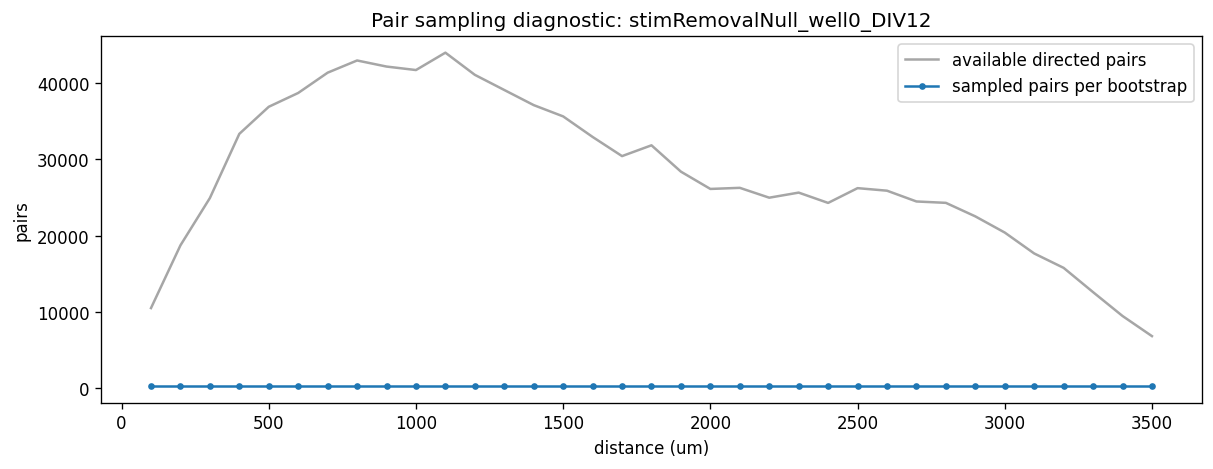

,distance_bin_center_um,available_directed_pairs,sampled_directed_pairs
0,100.0,10484,250
1,200.0,18724,250
2,300.0,24936,250
3,400.0,33362,250
4,500.0,36920,250
5,600.0,38734,250
6,700.0,41398,250
7,800.0,43000,250
8,900.0,42202,250
9,1000.0,41744,250


In [220]:
diagnostic_item = activity_results[0]
diagnostic_coords = electrode_coords_um(diagnostic_item["recording"].layout)
diagnostic_available = np.asarray([e for e in diagnostic_item["refs"] if int(e) in diagnostic_coords.index], dtype=int)
diagnostic_pair_catalog = build_pair_catalog(diagnostic_available, diagnostic_coords)
diagnostic_sampled_pairs = sample_pair_catalog(
    diagnostic_pair_catalog,
    diagnostic_available,
    np.random.default_rng(int(SYNC_RANDOM_SEED)),
)

catalog_counts = (
    diagnostic_pair_catalog
    .groupby("distance_bin_center_um", as_index=False)
    .size()
    .rename(columns={"size": "available_directed_pairs"})
)
sampled_counts = (
    diagnostic_sampled_pairs
    .groupby("distance_bin_center_um", as_index=False)
    .size()
    .rename(columns={"size": "sampled_directed_pairs"})
)
pair_sampling_diagnostic = catalog_counts.merge(sampled_counts, on="distance_bin_center_um", how="left").fillna({"sampled_directed_pairs": 0})

fig, ax = plt.subplots(figsize=(10, 3.8), constrained_layout=True)
ax.plot(pair_sampling_diagnostic["distance_bin_center_um"], pair_sampling_diagnostic["available_directed_pairs"], color="0.65", label="available directed pairs")
ax.plot(pair_sampling_diagnostic["distance_bin_center_um"], pair_sampling_diagnostic["sampled_directed_pairs"], color="tab:blue", marker="o", ms=3, label="sampled pairs per bootstrap")
ax.set_xlabel("distance (um)")
ax.set_ylabel("pairs")
ax.set_title(f"Pair sampling diagnostic: {diagnostic_item['spec']['recording_id']}")
ax.legend(loc="best")
plt.show()

pair_sampling_diagnostic.head(12)

In [221]:
def synchrony_cache_settings():
    return {
        "DATASET": DATASET,
        "RUN_MODE": RUN_MODE,
        "wells": sorted(recording_spec_table["well"].astype(int).unique().tolist()),
        "divs": sorted(pd.Series(recording_spec_table["div"]).dropna().astype(int).unique().tolist()),
        "TEMPORAL_SUBSET": TEMPORAL_SUBSET,
        "SYNC_ACTIVITY_SCOPE": SYNC_ACTIVITY_SCOPE,
        "PRIMARY_LAG_WINDOW_MS": tuple(map(float, PRIMARY_LAG_WINDOW_MS)),
        "SYNC_LAG_WINDOWS_MS": [tuple(map(float, w)) for w in SYNC_LAG_WINDOWS_MS],
        "SYNC_EVALUATE_DIRECTED_LAG_WINDOWS": bool(SYNC_EVALUATE_DIRECTED_LAG_WINDOWS),
        "DISTANCE_BIN_UM": float(DISTANCE_BIN_UM),
        "MIN_DISTANCE_UM": float(MIN_DISTANCE_UM),
        "MAX_DISTANCE_UM": float(MAX_DISTANCE_UM),
        "SYNC_COMPUTE_METHOD": SYNC_COMPUTE_METHOD,
        "SYNC_MATRIX_BIN_MS": float(SYNC_MATRIX_BIN_MS),
        "SYNC_NULL_METHOD": SYNC_NULL_METHOD,
        "SYNC_JITTER_MS": float(SYNC_JITTER_MS),
        "SYNC_BOOTSTRAP_REPS": int(SYNC_BOOTSTRAP_REPS),
        "SYNC_N_SURROGATES": int(SYNC_N_SURROGATES),
        "SYNC_PAIR_SAMPLING": SYNC_PAIR_SAMPLING,
        "SYNC_PAIRS_PER_DISTANCE_BIN": int(SYNC_PAIRS_PER_DISTANCE_BIN),
        "SYNC_N_REF_ELECTRODES": int(SYNC_N_REF_ELECTRODES),
        "SYNC_N_TARGET_ELECTRODES": int(SYNC_N_TARGET_ELECTRODES),
        "SYNC_MIN_TRIGGER_SPIKES": int(SYNC_MIN_TRIGGER_SPIKES),
        "SYNC_NULL_STD_FLOOR": float(SYNC_NULL_STD_FLOOR),
        "SYNC_RANDOM_SEED": int(SYNC_RANDOM_SEED),
        "SMOKE_MODE": bool(SMOKE_MODE),
    }


def cache_path_for_settings():
    settings = synchrony_cache_settings()
    digest = hashlib.sha1(json.dumps(settings, sort_keys=True).encode("utf-8")).hexdigest()[:12]
    wells = "-".join(map(str, settings["wells"]))
    divs = "-".join(map(str, settings["divs"])) or "na"
    mode_tag = "smoke" if SMOKE_MODE else "full"
    name = f"sync_{DATASET}_{RUN_MODE}_w{wells}_d{divs}_{TEMPORAL_SUBSET}_{SYNC_NULL_METHOD}_{mode_tag}_{digest}.pkl"
    return OUTPUT_ROOT / name


cache_path = cache_path_for_settings()
cache_path.parent.mkdir(parents=True, exist_ok=True)

if cache_path.exists() and not FORCE_RECOMPUTE:
    with cache_path.open("rb") as f:
        cached = pickle.load(f)
    recording_summary = cached["recording_summary"]
    interval_summary = cached["interval_summary"]
    pair_sync_samples = cached["pair_sync_samples"]
    print(f"Loaded cached synchrony result: {cache_path}")
else:
    rng = np.random.default_rng(int(SYNC_RANDOM_SEED))
    chunks = []
    for item in activity_results:
        print(f"Processing {item['spec']['recording_id']} with {len(item['selected_intervals'])} selected intervals")
        chunk = bootstrap_recording_synchrony(item, rng=rng)
        if not chunk.empty:
            chunks.append(chunk)
    pair_sync_samples = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()
    cache_settings = synchrony_cache_settings()
    with cache_path.open("wb") as f:
        pickle.dump(
            {
                "recording_summary": recording_summary,
                "interval_summary": interval_summary,
                "pair_sync_samples": pair_sync_samples,
                "settings": cache_settings,
            },
            f,
        )
    print(f"Saved synchrony result cache: {cache_path}")

if pair_sync_samples.empty:
    raise ValueError("No synchrony samples were produced. Check selected intervals, electrode selection, and bootstrap settings.")

pair_sync_samples.head()

Loaded cached synchrony result: /Users/danielrebbin/Documents/GitHub/ephax/outputs/activity_distance/sync_stim_removal_null_single_div_all_wells_w0-1-2-3-4-5_d12_burst_interval_jitter_smoke_997b76f390af.pkl


,dataset,well,div,recording_id,activity_scope,bootstrap_idx,compute_method,null_method,lag_start_ms,lag_stop_ms,distance_bin_idx,distance_bin_center_um,n_pairs,n_trigger_spikes,p_obs,p_obs_median,p_null_mean,p_null_median,excess_sync,excess_sync_median,z_sync,z_sync_median,log_ratio,log_ratio_median
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,0,matrix,interval_jitter,-2.0,2.0,0,100.0,9544,493629,0.081798,0.045455,0.056532,0.041509,0.025265,0.0,0.955324,-0.5,0.045324,0.0
1,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,0,matrix,interval_jitter,-2.0,2.0,1,200.0,17078,892860,0.080785,0.045455,0.056923,0.042105,0.023862,0.0,0.961380,-0.5,0.038126,0.0
2,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,0,matrix,interval_jitter,-2.0,2.0,2,300.0,22498,1161973,0.079739,0.042857,0.056303,0.040669,0.023436,0.0,0.929593,-0.5,0.026209,0.0
3,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,0,matrix,interval_jitter,-2.0,2.0,3,400.0,30176,1542486,0.076104,0.038611,0.055169,0.040000,0.020935,0.0,0.824114,-0.5,-0.000541,0.0
4,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,0,matrix,interval_jitter,-2.0,2.0,4,500.0,33383,1674995,0.074820,0.037037,0.054466,0.039024,0.020354,0.0,0.883260,-0.5,-0.002955,0.0


## Validation and Distance-Binned Summaries

In [222]:
if "distance_um" in pair_sync_samples.columns:
    pair_sync_samples = add_distance_bins(pair_sync_samples)
else:
    pair_sync_samples = pair_sync_samples.copy()

assert pair_sync_samples["p_obs"].between(0, 1).all(), "p_obs outside [0, 1]"
assert pair_sync_samples["p_null_mean"].between(0, 1).all(), "p_null_mean outside [0, 1]"
assert pair_sync_samples["excess_sync"].between(-1, 1).all(), "excess_sync outside [-1, 1]"
if {"ref_electrode", "target_electrode"}.issubset(pair_sync_samples.columns):
    assert not (pair_sync_samples["ref_electrode"] == pair_sync_samples["target_electrode"]).any(), "self-pairs were not excluded"
if "distance_um" in pair_sync_samples.columns:
    assert pair_sync_samples["distance_um"].between(MIN_DISTANCE_UM, MAX_DISTANCE_UM).all(), "distance outside configured range"

print(f"Synchrony rows: {len(pair_sync_samples):,}")
print(f"Unique recording ids: {pair_sync_samples['recording_id'].nunique()}")
print(f"Unique lag windows: {pair_sync_samples[['lag_start_ms', 'lag_stop_ms']].drop_duplicates().shape[0]}")
print("Compute method:", pair_sync_samples.get("compute_method", pd.Series(["pair_loop"])).iloc[0])
pair_sync_samples[["p_obs", "p_null_mean", "excess_sync", "z_sync", "log_ratio"]].describe()

Synchrony rows: 1,050
Unique recording ids: 6
Unique lag windows: 1
Compute method: matrix


,p_obs,p_null_mean,excess_sync,z_sync,log_ratio
count,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000
mean,0.069100,0.054485,0.014614,0.730851,-0.039214
std,0.009091,0.005727,0.005145,0.213059,0.055911
min,0.047923,0.042317,0.001650,0.014420,-0.179491
25%,0.062915,0.050266,0.011028,0.581792,-0.075096
50%,0.069003,0.054282,0.014129,0.684952,-0.040819
75%,0.074395,0.057948,0.017498,0.862747,-0.004108
max,0.095020,0.073658,0.029849,1.619510,0.126817


In [223]:
def bootstrap_ci(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return pd.Series({"ci_low": np.nan, "ci_high": np.nan})
    return pd.Series({"ci_low": float(np.quantile(values, 0.025)), "ci_high": float(np.quantile(values, 0.975))})


if "compute_method" in pair_sync_samples.columns and (pair_sync_samples["compute_method"] == "matrix").all():
    # Matrix output is already one row per recording/bootstrap/distance bin/window.
    per_bootstrap_bin = pair_sync_samples.copy()
else:
    # Pair-loop fallback: first average pairs inside each bootstrap/distance bin.
    per_bootstrap_bin = (
        pair_sync_samples
        .groupby(
            [
                "dataset", "well", "div", "recording_id", "activity_scope",
                "lag_start_ms", "lag_stop_ms", "bootstrap_idx", "distance_bin_center_um",
            ],
            dropna=False,
        )
        .agg(
            n_pairs=("distance_um", "size"),
            n_trigger_spikes=("n_trigger_spikes", "sum"),
            p_obs=("p_obs", "mean"),
            p_null_mean=("p_null_mean", "mean"),
            excess_sync=("excess_sync", "mean"),
            z_sync=("z_sync", "mean"),
            log_ratio=("log_ratio", "mean"),
        )
        .reset_index()
    )

per_bootstrap_bin = per_bootstrap_bin[per_bootstrap_bin["n_pairs"] >= MIN_PAIRS_PER_DISTANCE_BIN].copy()
summary_groups = [
    "dataset", "well", "div", "recording_id", "activity_scope",
    "lag_start_ms", "lag_stop_ms", "distance_bin_center_um",
]

def _sem(x):
    x = np.asarray(x, dtype=float)
    n = np.count_nonzero(np.isfinite(x))
    return float(np.nanstd(x, ddof=1) / np.sqrt(n)) if n > 1 else np.nan

distance_bin_summary = (
    per_bootstrap_bin
    .groupby(summary_groups, dropna=False)
    .agg(
        n_bootstraps=("bootstrap_idx", "nunique"),
        n_pairs_median=("n_pairs", "median"),
        p_obs_mean=("p_obs", "mean"),
        p_obs_median=("p_obs", "median"),
        p_obs_sem=("p_obs", _sem),
        p_null_mean=("p_null_mean", "mean"),
        excess_sync_mean=("excess_sync", "mean"),
        excess_sync_median=("excess_sync", "median"),
        z_sync_mean=("z_sync", "mean"),
        z_sync_median=("z_sync", "median"),
        log_ratio_mean=("log_ratio", "mean"),
        log_ratio_median=("log_ratio", "median"),
    )
    .reset_index()
)

ci_frames = []
for metric in ["p_obs", "excess_sync", "z_sync", "log_ratio"]:
    ci = per_bootstrap_bin.groupby(summary_groups, dropna=False)[metric].apply(bootstrap_ci).unstack().reset_index()
    ci = ci.rename(columns={"ci_low": f"{metric}_ci_low", "ci_high": f"{metric}_ci_high"})
    ci_frames.append(ci)
for ci in ci_frames:
    distance_bin_summary = distance_bin_summary.merge(ci, on=summary_groups, how="left")

primary_mask = (
    (distance_bin_summary["lag_start_ms"] == float(PRIMARY_LAG_WINDOW_MS[0]))
    & (distance_bin_summary["lag_stop_ms"] == float(PRIMARY_LAG_WINDOW_MS[1]))
)
primary_distance_summary = distance_bin_summary.loc[primary_mask].copy()

distance_bin_summary.head()

,dataset,well,div,recording_id,activity_scope,lag_start_ms,lag_stop_ms,distance_bin_center_um,n_bootstraps,n_pairs_median,p_obs_mean,p_obs_median,p_obs_sem,p_null_mean,excess_sync_mean,excess_sync_median,z_sync_mean,z_sync_median,log_ratio_mean,log_ratio_median,p_obs_ci_low,p_obs_ci_high,excess_sync_ci_low,excess_sync_ci_high,z_sync_ci_low,z_sync_ci_high,log_ratio_ci_low,log_ratio_ci_high
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,-2.0,2.0,100.0,5,9480.0,0.077462,0.075116,0.002933,0.053789,0.023673,0.021719,0.944355,0.952839,0.030509,0.031825,0.070368,0.085933,0.020844,0.028683,0.826995,1.134763,0.011096,0.045169
1,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,-2.0,2.0,200.0,5,16987.0,0.076598,0.074843,0.003019,0.053998,0.022599,0.021270,0.932581,0.946760,0.027265,0.029877,0.068702,0.085136,0.019066,0.028000,0.824973,1.043941,0.011616,0.038783
2,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,-2.0,2.0,300.0,5,22401.0,0.076437,0.074637,0.002872,0.053715,0.022722,0.021510,0.949617,0.913443,0.019182,0.017351,0.068883,0.084788,0.019263,0.027712,0.863918,1.129089,0.010049,0.031402
3,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,-2.0,2.0,400.0,5,29939.0,0.072926,0.071215,0.002827,0.052448,0.020479,0.019444,0.862089,0.831188,-0.000770,-0.004682,0.065555,0.081209,0.017223,0.025610,0.763409,1.028841,-0.012327,0.020731
4,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,-2.0,2.0,500.0,5,33064.0,0.071713,0.069860,0.002999,0.051518,0.020195,0.019269,0.875378,0.870104,-0.000638,-0.005304,0.063768,0.080496,0.016573,0.025410,0.743558,1.014940,-0.011847,0.023943


## Distance Summary Plots

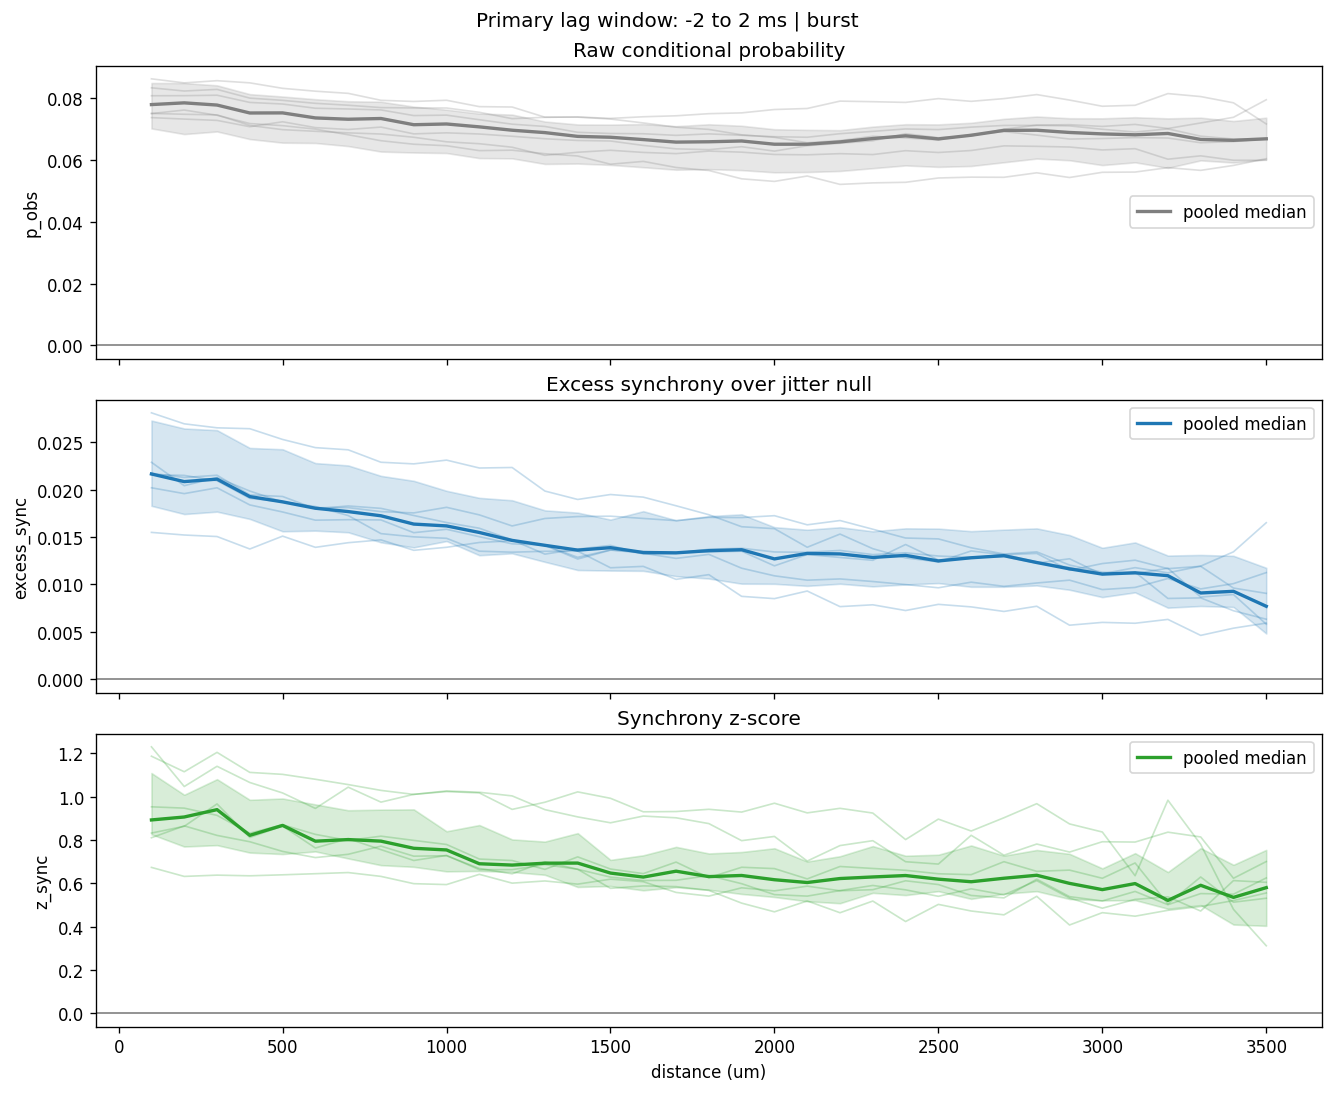

In [224]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, constrained_layout=True)
metrics = [
    ("p_obs", "Raw conditional probability", "tab:gray"),
    ("excess_sync", "Excess synchrony over jitter null", "tab:blue"),
    ("z_sync", "Synchrony z-score", "tab:green"),
]

for ax, (prefix, title, color) in zip(axes, metrics):
    for recording_id, df_i in primary_distance_summary.groupby("recording_id"):
        x = df_i["distance_bin_center_um"].to_numpy(dtype=float)
        y = df_i[f"{prefix}_median"].to_numpy(dtype=float) if f"{prefix}_median" in df_i else df_i[f"{prefix}_mean"].to_numpy(dtype=float)
        ax.plot(x, y, color=color, alpha=0.25, lw=1.0)

    pooled = (
        primary_distance_summary
        .groupby("distance_bin_center_um", as_index=False)
        .agg(
            median=(f"{prefix}_median" if f"{prefix}_median" in primary_distance_summary else f"{prefix}_mean", "median"),
            low=(f"{prefix}_ci_low", "median") if f"{prefix}_ci_low" in primary_distance_summary else (f"{prefix}_mean", "median"),
            high=(f"{prefix}_ci_high", "median") if f"{prefix}_ci_high" in primary_distance_summary else (f"{prefix}_mean", "median"),
        )
    )
    ax.plot(pooled["distance_bin_center_um"], pooled["median"], color=color, lw=2.0, label="pooled median")
    if "low" in pooled and "high" in pooled:
        ax.fill_between(pooled["distance_bin_center_um"], pooled["low"], pooled["high"], color=color, alpha=0.18)
    ax.axhline(0.0, color="0.5", lw=1.0)
    ax.set_ylabel(prefix)
    ax.set_title(title)
    ax.legend(loc="best")

axes[-1].set_xlabel("distance (um)")
fig.suptitle(f"Primary lag window: {PRIMARY_LAG_WINDOW_MS[0]:g} to {PRIMARY_LAG_WINDOW_MS[1]:g} ms | {SYNC_ACTIVITY_SCOPE}")
plt.show()

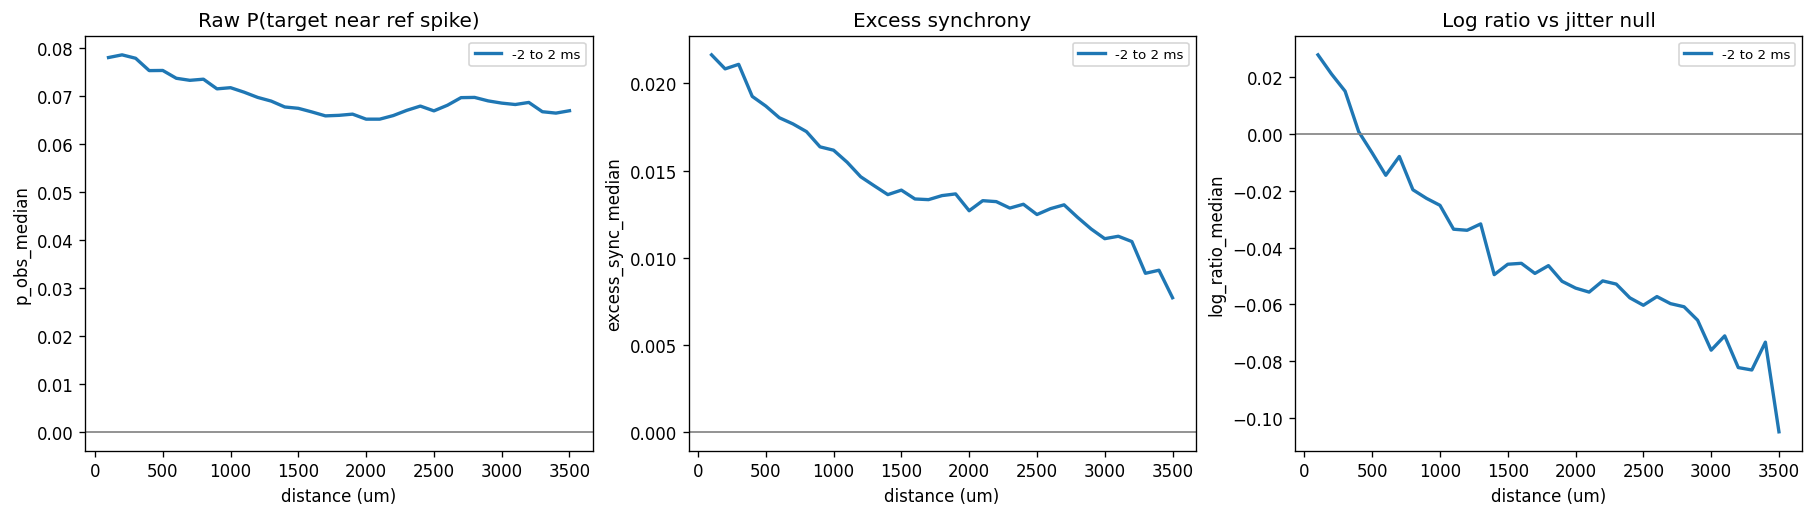

In [225]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
plot_metrics = [
    ("p_obs_median", "Raw P(target near ref spike)", "tab:gray"),
    ("excess_sync_median", "Excess synchrony", "tab:blue"),
    ("log_ratio_median", "Log ratio vs jitter null", "tab:purple"),
]
for ax, (metric, title, color) in zip(axes, plot_metrics):
    for (lag_start, lag_stop), df_lag in distance_bin_summary.groupby(["lag_start_ms", "lag_stop_ms"]):
        pooled = df_lag.groupby("distance_bin_center_um", as_index=False)[metric].median()
        alpha = 1.0 if (lag_start, lag_stop) == tuple(PRIMARY_LAG_WINDOW_MS) else 0.45
        lw = 2.0 if alpha == 1.0 else 1.0
        ax.plot(
            pooled["distance_bin_center_um"],
            pooled[metric],
            lw=lw,
            alpha=alpha,
            label=f"{lag_start:g} to {lag_stop:g} ms",
        )
    ax.axhline(0.0, color="0.5", lw=1.0)
    ax.set_title(title)
    ax.set_xlabel("distance (um)")
    ax.set_ylabel(metric)
    ax.legend(loc="best", fontsize=8)
plt.show()

## Nested Model Comparison: Axonal-Only vs Axonal-Ephaptic

Fit two nested models to all recording/bootstrap distance-bin rows for the primary lag window:

```text
axonal-only:     offset + amplitude * exp(-distance / axonal_decay_um)
axonal-ephaptic: offset + amplitude * exp(-distance / axonal_decay_um)
                  + coefficient * Figure1Correlation(distance, lambda_eph_um)
```

The oscillatory correlation-wave definition is the same one called by Figure 1: `45 Hz`, `v_eph=0.1 m/s`, and `v_ax=0.8 m/s`, giving a theoretical wavelength of `2539.68 um`. Unlike the Figure 1 visualization, this fit does not hold either attenuation length fixed. Both `axonal_decay_um` and `lambda_eph_um` are estimated from the synchrony data.

The classical nested F-test is reported as a descriptive model-comparison statistic. Because bootstrap curves are dependent resamples, and `lambda_eph_um` is not identifiable when the correlation coefficient is zero, cluster-bootstrap confidence intervals and the sign stability of the ephaptic coefficient are the primary uncertainty estimates.


In [ ]:
def figure1_correlation_kernel(distance_um, lambda_eph_um):
    """Figure 1 correlation wave with a fitted spatial attenuation length."""
    return FIGURE1_WAVE_CONFIG.correlation_gain * correlation_function(
        np.asarray(distance_um, dtype=float),
        FIGURE1_WAVE_CONFIG.hz,
        FIGURE1_WAVE_CONFIG.v_eph_um_s,
        FIGURE1_WAVE_CONFIG.v_ax_um_s,
        float(lambda_eph_um),
    )


def axonal_only_model(distance_um, offset, amplitude, axonal_decay_um):
    distance_um = np.asarray(distance_um, dtype=float)
    return offset + amplitude * np.exp(-distance_um / axonal_decay_um)


def axonal_ephaptic_model(
    distance_um, offset, amplitude, axonal_decay_um, correlation_coefficient, lambda_eph_um
):
    return (
        axonal_only_model(distance_um, offset, amplitude, axonal_decay_um)
        + correlation_coefficient * figure1_correlation_kernel(distance_um, lambda_eph_um)
    )


def _information_criteria(rss, n_obs, n_params):
    rss = max(float(rss), np.finfo(float).tiny)
    return {
        "aic": float(n_obs * np.log(rss / n_obs) + 2 * n_params),
        "bic": float(n_obs * np.log(rss / n_obs) + n_params * np.log(n_obs)),
    }


def fit_nested_distance_models(rows):
    x = rows["distance_bin_center_um"].to_numpy(dtype=float)
    y = rows["excess_sync"].to_numpy(dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if x.size < 10:
        raise ValueError("Need at least ten finite distance-bin rows for nested model fitting.")

    offset0 = float(np.nanmedian(y[x >= np.nanquantile(x, 0.75)]))
    amplitude0 = float(max(np.nanmax(y) - offset0, 1e-6))
    axonal_params, _ = curve_fit(
        axonal_only_model,
        x,
        y,
        p0=[offset0, amplitude0, MODEL_INITIAL_AXONAL_DECAY_UM],
        bounds=([-np.inf, 0.0, 10.0], [np.inf, np.inf, 1e6]),
        maxfev=50000,
    )

    # lambda_eph_um and its coefficient interact nonlinearly. Use multiple starts
    # and retain the lowest-RSS converged fit rather than relying on one seed.
    coefficient_scale = float(max(np.ptp(y), 1e-6))
    ephaptic_candidates = []
    for lambda0 in [500.0, 1500.0, MODEL_INITIAL_LAMBDA_EPH_UM, 10000.0, 50000.0]:
        for coefficient0 in [-coefficient_scale, coefficient_scale]:
            try:
                params, _ = curve_fit(
                    axonal_ephaptic_model,
                    x,
                    y,
                    p0=[*axonal_params, coefficient0, lambda0],
                    bounds=([-np.inf, 0.0, 10.0, -np.inf, 50.0], [np.inf, np.inf, 1e6, np.inf, 1e6]),
                    maxfev=100000,
                )
            except Exception:
                continue
            residual = y - axonal_ephaptic_model(x, *params)
            ephaptic_candidates.append((float(np.sum(residual ** 2)), params))
    if not ephaptic_candidates:
        raise ValueError("No axonal-ephaptic model initialization converged.")
    _, ephaptic_params = min(ephaptic_candidates, key=lambda item: item[0])

    pred_axonal = axonal_only_model(x, *axonal_params)
    pred_ephaptic = axonal_ephaptic_model(x, *ephaptic_params)
    rss_axonal = float(np.sum((y - pred_axonal) ** 2))
    rss_ephaptic = float(np.sum((y - pred_ephaptic) ** 2))
    n_obs = int(x.size)
    df_num = len(ephaptic_params) - len(axonal_params)
    df_den = n_obs - len(ephaptic_params)
    improvement = max(0.0, rss_axonal - rss_ephaptic)
    f_stat = float((improvement / df_num) / (rss_ephaptic / df_den)) if df_den > 0 and rss_ephaptic > 0 else np.nan
    f_p_value = float(f_distribution.sf(f_stat, df_num, df_den)) if np.isfinite(f_stat) else np.nan
    tss = float(np.sum((y - np.mean(y)) ** 2))
    axonal_ic = _information_criteria(rss_axonal, n_obs, len(axonal_params))
    ephaptic_ic = _information_criteria(rss_ephaptic, n_obs, len(ephaptic_params))
    return {
        "n_obs": n_obs,
        "axonal_params": axonal_params,
        "ephaptic_params": ephaptic_params,
        "rss_axonal": rss_axonal,
        "rss_ephaptic": rss_ephaptic,
        "rss_improvement_fraction": float(improvement / rss_axonal) if rss_axonal > 0 else np.nan,
        "r2_axonal": float(1.0 - rss_axonal / tss) if tss > 0 else np.nan,
        "r2_ephaptic": float(1.0 - rss_ephaptic / tss) if tss > 0 else np.nan,
        "f_stat": f_stat,
        "f_p_value": f_p_value,
        "delta_aic_ephaptic_minus_axonal": float(ephaptic_ic["aic"] - axonal_ic["aic"]),
        "delta_bic_ephaptic_minus_axonal": float(ephaptic_ic["bic"] - axonal_ic["bic"]),
    }


def bootstrap_nested_distance_models(rows, distance_grid_um, n_reps=1000, seed=0):
    rows = rows.copy()
    rows["curve_id"] = rows["recording_id"].astype(str) + "::" + rows["bootstrap_idx"].astype(str)
    curve_ids = rows["curve_id"].drop_duplicates().to_numpy()
    if curve_ids.size == 0:
        raise ValueError("No recording/bootstrap curves available for model bootstrap.")
    grouped = {curve_id: rows.loc[rows["curve_id"] == curve_id] for curve_id in curve_ids}
    rng = np.random.default_rng(seed)
    metric_rows = []
    prediction_rows = []
    for bootstrap_idx in range(int(n_reps)):
        sampled_ids = rng.choice(curve_ids, size=curve_ids.size, replace=True)
        sampled = pd.concat([grouped[curve_id] for curve_id in sampled_ids], ignore_index=True)
        try:
            fit = fit_nested_distance_models(sampled)
        except Exception:
            continue
        metric_rows.append({
            "bootstrap_idx": bootstrap_idx,
            "axonal_offset": fit["axonal_params"][0],
            "axonal_amplitude": fit["axonal_params"][1],
            "axonal_decay_um": fit["axonal_params"][2],
            "ephaptic_offset": fit["ephaptic_params"][0],
            "ephaptic_amplitude": fit["ephaptic_params"][1],
            "ephaptic_axonal_decay_um": fit["ephaptic_params"][2],
            "correlation_coefficient": fit["ephaptic_params"][3],
            "lambda_eph_um": fit["ephaptic_params"][4],
            "rss_improvement_fraction": fit["rss_improvement_fraction"],
            "delta_aic_ephaptic_minus_axonal": fit["delta_aic_ephaptic_minus_axonal"],
            "delta_bic_ephaptic_minus_axonal": fit["delta_bic_ephaptic_minus_axonal"],
        })
        prediction_rows.append(pd.DataFrame({
            "bootstrap_idx": bootstrap_idx,
            "distance_um": distance_grid_um,
            "axonal_only": axonal_only_model(distance_grid_um, *fit["axonal_params"]),
            "axonal_ephaptic": axonal_ephaptic_model(distance_grid_um, *fit["ephaptic_params"]),
        }))
    return pd.DataFrame(metric_rows), pd.concat(prediction_rows, ignore_index=True) if prediction_rows else pd.DataFrame()


def percentile_interval(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan, np.nan
    return tuple(float(v) for v in np.quantile(values, [0.5, 0.025, 0.975]))


primary_model_rows = per_bootstrap_bin.loc[
    (per_bootstrap_bin["lag_start_ms"] == float(PRIMARY_LAG_WINDOW_MS[0]))
    & (per_bootstrap_bin["lag_stop_ms"] == float(PRIMARY_LAG_WINDOW_MS[1]))
].copy()
primary_model_rows = primary_model_rows.dropna(subset=["distance_bin_center_um", "excess_sync"])
if primary_model_rows.empty:
    raise ValueError("No primary-lag distance-bin rows available for model fitting.")

full_data_model_fit = fit_nested_distance_models(primary_model_rows)
distance_grid_um = np.linspace(MIN_DISTANCE_UM, MAX_DISTANCE_UM, 400)
model_fit_bootstrap, model_prediction_bootstrap = bootstrap_nested_distance_models(
    primary_model_rows,
    distance_grid_um,
    n_reps=MODEL_FIT_BOOTSTRAP_REPS,
    seed=MODEL_FIT_RANDOM_SEED,
)
if model_fit_bootstrap.empty:
    raise ValueError("All nested-model bootstrap fits failed.")

model_prediction_summary = (
    model_prediction_bootstrap
    .groupby("distance_um", as_index=False)
    .agg(
        axonal_only_median=("axonal_only", "median"),
        axonal_only_ci_low=("axonal_only", lambda x: np.quantile(x, 0.025)),
        axonal_only_ci_high=("axonal_only", lambda x: np.quantile(x, 0.975)),
        axonal_ephaptic_median=("axonal_ephaptic", "median"),
        axonal_ephaptic_ci_low=("axonal_ephaptic", lambda x: np.quantile(x, 0.025)),
        axonal_ephaptic_ci_high=("axonal_ephaptic", lambda x: np.quantile(x, 0.975)),
    )
)

parameter_columns = [
    "axonal_offset", "axonal_amplitude", "axonal_decay_um",
    "ephaptic_offset", "ephaptic_amplitude", "ephaptic_axonal_decay_um",
    "correlation_coefficient", "lambda_eph_um", "rss_improvement_fraction",
    "delta_aic_ephaptic_minus_axonal", "delta_bic_ephaptic_minus_axonal",
]
model_parameter_summary = pd.DataFrame([
    {"parameter": column, "median": percentile_interval(model_fit_bootstrap[column])[0],
     "ci_low": percentile_interval(model_fit_bootstrap[column])[1],
     "ci_high": percentile_interval(model_fit_bootstrap[column])[2]}
    for column in parameter_columns
])
coefficient_values = model_fit_bootstrap["correlation_coefficient"].to_numpy(dtype=float)
bootstrap_two_sided_p = float(2.0 * min(np.mean(coefficient_values <= 0), np.mean(coefficient_values >= 0)))

model_fit_comparison = pd.DataFrame([{
    "n_distance_bin_rows": full_data_model_fit["n_obs"],
    "n_recording_bootstrap_curves": primary_model_rows[["recording_id", "bootstrap_idx"]].drop_duplicates().shape[0],
    "figure1_frequency_hz": FIGURE1_WAVE_CONFIG.hz,
    "figure1_wavelength_um": FIGURE1_WAVE_CONFIG.wavelength_um,
    "rss_axonal_only": full_data_model_fit["rss_axonal"],
    "rss_axonal_ephaptic": full_data_model_fit["rss_ephaptic"],
    "rss_improvement_fraction": full_data_model_fit["rss_improvement_fraction"],
    "r2_axonal_only": full_data_model_fit["r2_axonal"],
    "r2_axonal_ephaptic": full_data_model_fit["r2_ephaptic"],
    "fitted_axonal_decay_um_axonal_only": full_data_model_fit["axonal_params"][2],
    "fitted_axonal_decay_um_axonal_ephaptic": full_data_model_fit["ephaptic_params"][2],
    "fitted_lambda_eph_um": full_data_model_fit["ephaptic_params"][4],
    "nested_f_stat_descriptive": full_data_model_fit["f_stat"],
    "nested_f_p_value_descriptive": full_data_model_fit["f_p_value"],
    "bootstrap_two_sided_p_coefficient": bootstrap_two_sided_p,
    "delta_aic_ephaptic_minus_axonal": full_data_model_fit["delta_aic_ephaptic_minus_axonal"],
    "delta_bic_ephaptic_minus_axonal": full_data_model_fit["delta_bic_ephaptic_minus_axonal"],
    "successful_cluster_bootstrap_fits": len(model_fit_bootstrap),
}])

print(f"Figure 1 correlation wavelength: {FIGURE1_WAVE_CONFIG.wavelength_um:.2f} um")
print(f"Fitted axonal-only decay: {full_data_model_fit['axonal_params'][2]:.1f} um")
print(f"Fitted axonal-ephaptic decay: {full_data_model_fit['ephaptic_params'][2]:.1f} um")
print(f"Fitted ephaptic attenuation length: {full_data_model_fit['ephaptic_params'][4]:.1f} um")
print(f"Successful cluster bootstrap fits: {len(model_fit_bootstrap):,}/{MODEL_FIT_BOOTSTRAP_REPS:,}")
model_fit_comparison


In [ ]:
pooled_primary = (
    primary_distance_summary
    .groupby("distance_bin_center_um", as_index=False)
    .agg(
        excess_sync_median=("excess_sync_median", "median"),
        excess_sync_ci_low=("excess_sync_ci_low", "median"),
        excess_sync_ci_high=("excess_sync_ci_high", "median"),
    )
)

fig, axes = plt.subplots(3, 1, figsize=(11, 10), constrained_layout=True)

x = pooled_primary["distance_bin_center_um"].to_numpy(dtype=float)
y = pooled_primary["excess_sync_median"].to_numpy(dtype=float)
axes[0].fill_between(
    x, pooled_primary["excess_sync_ci_low"], pooled_primary["excess_sync_ci_high"],
    color="tab:blue", alpha=0.16, label="distance-bin bootstrap CI",
)
axes[0].plot(x, y, marker="o", color="tab:blue", lw=1.5, label="corrected synchrony")
axes[0].fill_between(
    model_prediction_summary["distance_um"],
    model_prediction_summary["axonal_only_ci_low"],
    model_prediction_summary["axonal_only_ci_high"],
    color="black", alpha=0.12,
)
axes[0].plot(
    model_prediction_summary["distance_um"], model_prediction_summary["axonal_only_median"],
    color="black", lw=1.8, label="axonal-only exponential",
)
axes[0].fill_between(
    model_prediction_summary["distance_um"],
    model_prediction_summary["axonal_ephaptic_ci_low"],
    model_prediction_summary["axonal_ephaptic_ci_high"],
    color="crimson", alpha=0.14,
)
axes[0].plot(
    model_prediction_summary["distance_um"], model_prediction_summary["axonal_ephaptic_median"],
    color="crimson", lw=1.8, label="exponential + Figure 1 correlation",
)
axes[0].set_ylabel("excess synchrony")
axes[0].set_title("Nested model fits to baseline-corrected synchrony")
axes[0].legend(loc="best")

axonal_full = axonal_only_model(x, *full_data_model_fit["axonal_params"])
ephaptic_full = axonal_ephaptic_model(x, *full_data_model_fit["ephaptic_params"])
axes[1].axhline(0.0, color="0.5", lw=1.0)
axes[1].plot(x, y - axonal_full, marker="o", color="black", label="residual: axonal-only")
axes[1].plot(x, y - ephaptic_full, marker="o", color="crimson", label="residual: axonal-ephaptic")
axes[1].set_ylabel("residual synchrony")
axes[1].set_title("Residual structure after each fit")
axes[1].legend(loc="best")

fitted_lambda_eph_um = float(full_data_model_fit["ephaptic_params"][4])
kernel_grid = figure1_correlation_kernel(distance_grid_um, fitted_lambda_eph_um)
coefficient = float(full_data_model_fit["ephaptic_params"][3])
axes[2].axhline(0.0, color="0.5", lw=1.0)
axes[2].plot(distance_grid_um, kernel_grid, color="tab:purple", label=f"Figure 1 wave, fitted lambda_eph={fitted_lambda_eph_um:.0f} um")
axes[2].plot(distance_grid_um, coefficient * kernel_grid, color="crimson", label="fitted coefficient * kernel")
axes[2].axvline(FIGURE1_WAVE_CONFIG.wavelength_um, color="0.3", ls="--", lw=1.2, label=f"wavelength={FIGURE1_WAVE_CONFIG.wavelength_um:.0f} um")
axes[2].set_xlabel("distance (um)")
axes[2].set_ylabel("kernel value")
axes[2].set_title("Figure 1 correlation wave with fitted attenuation")
axes[2].legend(loc="best")
plt.show()

model_parameter_summary


## Progression-Ready Tables

The following tables are intended as the handoff point for later reusable code and final figure assembly.

In [ ]:
print("recording_summary", recording_summary.shape)
print("interval_summary", interval_summary.shape)
print("pair_sync_samples", pair_sync_samples.shape)
print("distance_bin_summary", distance_bin_summary.shape)
print("model_fit_comparison", model_fit_comparison.shape)
print("model_parameter_summary", model_parameter_summary.shape)

required_common = {"dataset", "well", "div", "recording_id"}
for name, table in [
    ("recording_summary", recording_summary),
    ("interval_summary", interval_summary),
    ("pair_sync_samples", pair_sync_samples),
    ("distance_bin_summary", distance_bin_summary),
]:
    missing = required_common - set(table.columns)
    if missing:
        print(f"{name} missing common columns: {sorted(missing)}")

recording_summary.head(), interval_summary.head(), distance_bin_summary.head(), model_fit_comparison, model_parameter_summary
